# Testing qibo_qec Module

Basic imports and graphic settings:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

Basic Qibo Circuit creation:

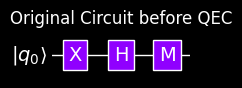

In [2]:
qc = Circuit(1)

qc.add(gates.X(0))

qc.add(gates.H(0))

qc.add(gates.M(0))

plot_circuit(qc, style=custom_style)
plt.title("Original Circuit before QEC")
plt.show()

Application of Quantum Error Correction:

Initialized QEC with code type: bit_flip
Applying bit_flip code to a circuit with 3 qubit(s).


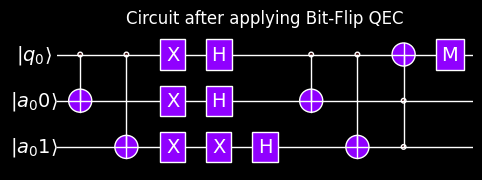

In [5]:
qec = QEC(code_type="bit_flip")
# encoded_circuit = qec.apply_code(qc)

test_gates = [gates.X(2)]  # Example test gate to introduce an error
encoded_circuit = qec.apply_code(qc, test_gates=test_gates, correction=True)

plot_circuit(encoded_circuit, style=custom_style)
plt.title("Circuit after applying Bit-Flip QEC")
plt.show()

[Qibo 0.2.22|INFO|2025-11-18 23:41:33]: Using qibojit (numba) backend on /CPU:0
[Qibo 0.2.22|INFO|2025-11-18 23:41:33]: Using qibojit (numba) backend on /CPU:0


Counter({'0': 518, '1': 506})


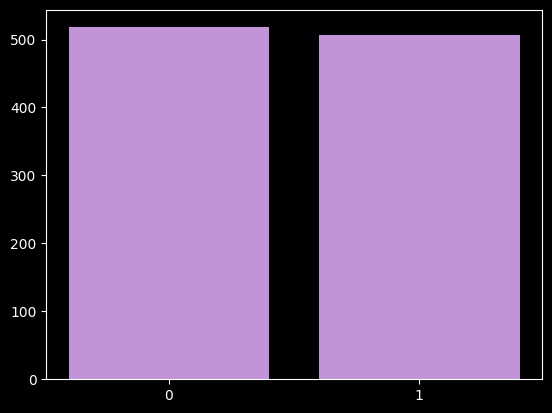

In [6]:
qibo.set_backend("qibojit")
qibo.set_device("/CPU:0")
qibo.set_threads(20)

res = encoded_circuit(nshots=2**10)

print(res.frequencies())

plt.bar(res.frequencies().keys(), res.frequencies().values(), color=QIBO_DEFAULT_COLOR)
plt.show()